# Pandas on meteorological data from the Max Planck Institute for Biogeochemistry

Credit: Some of the code in this tutorial is adapted from the excellent [TensorFlow tutorial on time series](https://www.tensorflow.org/tutorials/structured_data/time_series), which is licensed under the Apache-2.0 license. This is an excellent resource that you can consult if you want to study how to process time series with neural networks.

## Imports

In [ ]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

## `pandas` import

Import `pandas` in the standard way.

In [ ]:
# Your code here

### Solution

In [ ]:
import pandas as pd

## Downloading the dataset

In [ ]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)
csv_path

'/home/mog/.keras/datasets/jena_climate_2009_2016.csv'

## Reading data from the CSV file

Use `pandas.read_csv` to read the input file (stored at `csv_path`) in the `DataFrame` `df`.

You will need to make sure that the dates are parsed, and that the index column is `Date Time`.

In [ ]:
# Your code here

### Solution

In [ ]:
df = pd.read_csv(csv_path, parse_dates=True, index_col="Date Time")
df

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
2016-12-31 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
2016-12-31 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2


## Analyzing `df`

Study `df` with the means seen in class. Determine:

- The variables in the data set (the columns)
- The number of samples
- The time between two samples
- The characteristics of the numerical variables

In [ ]:
# Your code here

### Solution

In [ ]:
print(f"DataFrame shape : {df.shape}")
print(f"DataFrame columns: {', '.join(df.columns)}")
print(f"Time between two successive sample: {df.index[1] - df.index[0]}")
df.describe().transpose()

Forme de la DataFrame : (420551, 14)
Colonnes de la DataFrame : p (mbar), T (degC), Tpot (K), Tdew (degC), rh (%), VPmax (mbar), VPact (mbar), VPdef (mbar), sh (g/kg), H2OC (mmol/mol), rho (g/m**3), wv (m/s), max. wv (m/s), wd (deg)
Temps entre deux échantillons : 0 days 00:10:00


,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


## Outliers correction

As can be seen above, two columns have wind speed values at `-9999.0`, which is of course outliers.

Correct these values by replacing them with `0`.

Then check with a call to `describe` that the correction has been applied.

In [ ]:
# Your code here

### Solution

In [ ]:
wv = df['wv (m/s)']
mask = df['wv (m/s)'] == -9999.0
wv[mask] = 0.0

max_wv = df['max. wv (m/s)']
mask = max_wv == -9999.0
max_wv[mask] = 0.0

## Resampling

As we saw in the previous question, the time interval between two samples is very small at this point.

Resample the dataset using the function [`pandas.DataFrame.resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) so that the measurements are averaged per day.

In [ ]:
# Your code here

### Solution

In [ ]:
df_resampled = df.resample("1D").mean()
print(f"DataFrame shape: {df_resampled.shape}")
print(f"Elapsed time between two samples: {df_resampled.index[1] - df_resampled.index[0]}")

Forme de la DataFrame : (2923, 14)
Temps entre deux échantillons : 1 days 00:00:00


## Comparisons

Calculate the average temperature and pressure (`T (degC)` and `p (mbar)`) for April 2014 and April 2015. Which was the warmer year? With the highest pressure?

In [ ]:
# Your code here

### Solution

In [ ]:
def compute_stats(date: str) -> pd.Series:
    return df_resampled.loc[date, ["T (degC)", "p (mbar)"]].mean()

stats_2014_04, stats_2015_04 = compute_stats("2014-04"), compute_stats("2015-04")
stats_2015_04 > stats_2014_04

T (degC)    False
p (mbar)     True
dtype: bool

## `DataFrame` visualization

Display the `T (degC)` & `p (mbar)` columns using the [`pandas.DataFrame.plot`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) method. You can use the argument `subplots=True` in your call to `plot` to make the result more readable.

The goal is to reproduce more succinctly the following result:

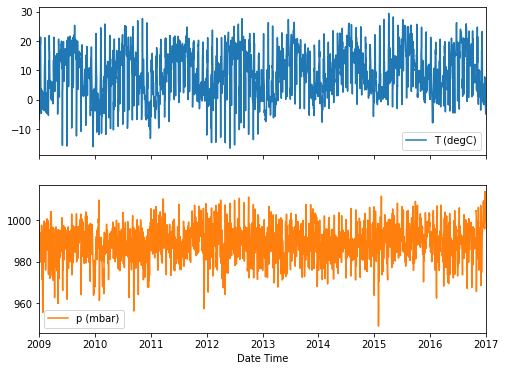

In [ ]:
_, (ax_t, ax_p) = plt.subplots(2, sharex=True)


def plot_column(ax: mpl.axes.Axes, column: str, color: str, xlabel: bool) -> None:
    x = df_resampled.index
    ax.plot(x, df_resampled[column], label=column, color=color)
    ax.set_xlim(x.min(), x.max())
    if xlabel:
        ax.set_xlabel(df_resampled.index.name)
    ax.legend()


plot_column(ax_t, "T (degC)", color="C0", xlabel=False)
plot_column(ax_p, "p (mbar)", color="C1", xlabel=True)
plt.show()

In [ ]:
# Your code here

### Solution

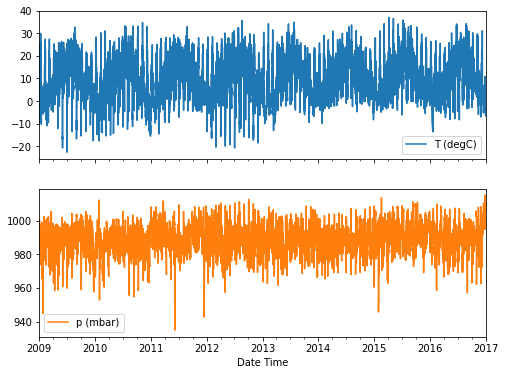

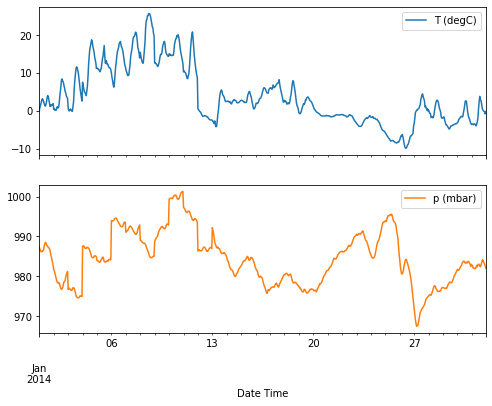

In [ ]:
df_resampled[["T (degC)", "p (mbar)"]].plot(subplots=True)
plt.show()

# For a specific month
df_resampled.loc["2014-01", ["T (degC)", "p (mbar)"]].plot(subplots=True)
plt.show()